# 01 — Synthetic Sanity Check

> **Where this fits:** This is the first notebook in the DDX analysis sequence. The overarching
> goal of this project is to design, calibrate, price, and compare funding-rate derivative
> products that hedge the tail risk of perpetual-swap funding for short-perp positions
> (e.g., Ethena-style reserve management). Before touching real exchange data, we validate
> the entire computational pipeline on synthetic data with known properties.

**What this notebook does:** We validate that all four DDX option products and the swap
benchmark behave correctly on *synthetic* funding-rate data generated by a two-regime
Markov model.

We confirm:
1. Payoff functions produce economically sensible distributions
2. Premium decomposition (pure, risk-loaded, target-Sharpe, full) works correctly
3. The hedge comparison framework (net-CF + loss-only lenses) produces meaningful results
4. Persistence-gated products (DAF, SDC) show clear sensitivity to regime persistence
5. The "sharpness" metric (ΔCVaR / Premium) differentiates products

Three scenarios are tested: **Base** (mild), **Persistence Stress** (long bad regimes),
and **Severity + Persistence Stress** (deep and long bad regimes).

**What comes next:** With the pipeline validated, notebooks 02–04 apply it to real
multi-venue funding data: descriptive analysis (NB02), parameter calibration (NB03),
and premium surfaces with uncertainty quantification (NB04).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
from pathlib import Path
import yaml

from ddx.models.simulation import two_regime_markov
from ddx.payoffs.floor import vanilla_floor
from ddx.payoffs.distress import distress_activated_floor, soft_duration_cover
from ddx.payoffs.stoploss import aggregate_stop_loss
from ddx.pricing.premium import compute_premium, full_premium, pure_premium
from ddx.risk.metrics import var, cvar, prob_loss, total_loss
from ddx.backtest.hedges import unhedged_cf, swap_hedge_cf, option_hedge_cf, option_hedge_loss

Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../reports/tables").mkdir(parents=True, exist_ok=True)

# Load synthetic scenario configs
with open("../configs/synthetic.yaml") as f:
    synth_cfg = yaml.safe_load(f)

COMMON = synth_cfg["common"]
SCENARIOS = synth_cfg["scenarios"]
N_INTERVALS = COMMON["n_intervals"]
N_PATHS = COMMON["n_paths_dev"]  # Use n_paths_final for publication
DT_YEARS = COMMON["dt_years"]
HORIZON_YEARS = N_INTERVALS * DT_YEARS
SEED = 42

print(f"Horizon: {N_INTERVALS} intervals = {N_INTERVALS * 8 / 24:.0f} days")
print(f"Paths: {N_PATHS:,}")
print(f"Horizon in years: {HORIZON_YEARS:.4f}")

Horizon: 90 intervals = 30 days
Paths: 20,000
Horizon in years: 0.0822


## 1. Generate Synthetic Paths

We generate Monte Carlo paths under three scenarios using a two-state Markov-switching model. Each path is a 30-day (90-interval) sequence of per-interval funding CFs.

In [2]:
paths = {}
for name, params in SCENARIOS.items():
    gen_params = {k: v for k, v in params.items() if k != "description"}
    paths[name] = two_regime_markov(
        n_intervals=N_INTERVALS,
        n_paths=N_PATHS,
        dt_years=DT_YEARS,
        seed=SEED,
        **gen_params,
    )
    p = paths[name]
    total_cf = p.sum(axis=1)
    print(f"\n=== {name}: {params['description']} ===")
    print(f"  Mean 30d CF:  {total_cf.mean():+.6f}")
    print(f"  Std 30d CF:   {total_cf.std():.6f}")
    print(f"  VaR 1%:       {np.quantile(total_cf, 0.01):+.6f}")
    print(f"  P(30d CF < 0): {(total_cf < 0).mean():.2%}")
    print(f"  Mean per-interval CF: {p.mean():.8f}")
    print(f"  % negative intervals: {(p < 0).mean():.2%}")


=== base: Mild bad regime, short episodes - funding mostly positive ===
  Mean 30d CF:  +0.007122
  Std 30d CF:   0.002263
  VaR 1%:       +0.000868
  P(30d CF < 0): 0.56%
  Mean per-interval CF: 0.00007913
  % negative intervals: 20.52%

=== persistence_stress: Same severity as base but bad regimes last much longer ===
  Mean 30d CF:  +0.002397
  Std 30d CF:   0.003648
  VaR 1%:       -0.006128
  P(30d CF < 0): 26.27%
  Mean per-interval CF: 0.00002664
  % negative intervals: 36.09%

=== severity_persistence_stress: More negative bad mean, higher bad vol, and longer episodes ===
  Mean 30d CF:  -0.001108
  Std 30d CF:   0.004658
  VaR 1%:       -0.012239
  P(30d CF < 0): 57.35%
  Mean per-interval CF: -0.00001231
  % negative intervals: 42.48%


## 2. Payoff Distributions

For each scenario, we compute the payoff of each product on every MC path and plot histograms. This validates that payoffs are non-negative and economically sensible.

**Baseline product parameters:**
- Floor: `d=0`, `cap=None` (full protection)
- DAF: `b=0`, `m=3`, `d=0`, `cap=None`
- SDC: `b=0`, `m=3`, `s=3`, `d=0`, `cap=None`
- ASL: `D=0.003`, `cap=None`

In [3]:
PRODUCTS = {
    "Floor": {"fn": vanilla_floor, "kwargs": {"deductible": 0.0}},
    "DAF (m=3)": {"fn": distress_activated_floor, "kwargs": {"threshold_b": 0.0, "streak_m": 3}},
    "SDC (m=3,s=3)": {"fn": soft_duration_cover, "kwargs": {"threshold_b": 0.0, "streak_m": 3, "ramp_s": 3}},
    "ASL (D=0.003)": {"fn": aggregate_stop_loss, "kwargs": {"deductible_D": 0.003}},
}

# Compute payoffs: dict[scenario][product] -> array of payoffs
payoff_results = {}
for sc_name, sc_paths in paths.items():
    payoff_results[sc_name] = {}
    for prod_name, spec in PRODUCTS.items():
        payoff_arr = np.array([spec["fn"](sc_paths[i], **spec["kwargs"]) for i in range(N_PATHS)])
        payoff_results[sc_name][prod_name] = payoff_arr

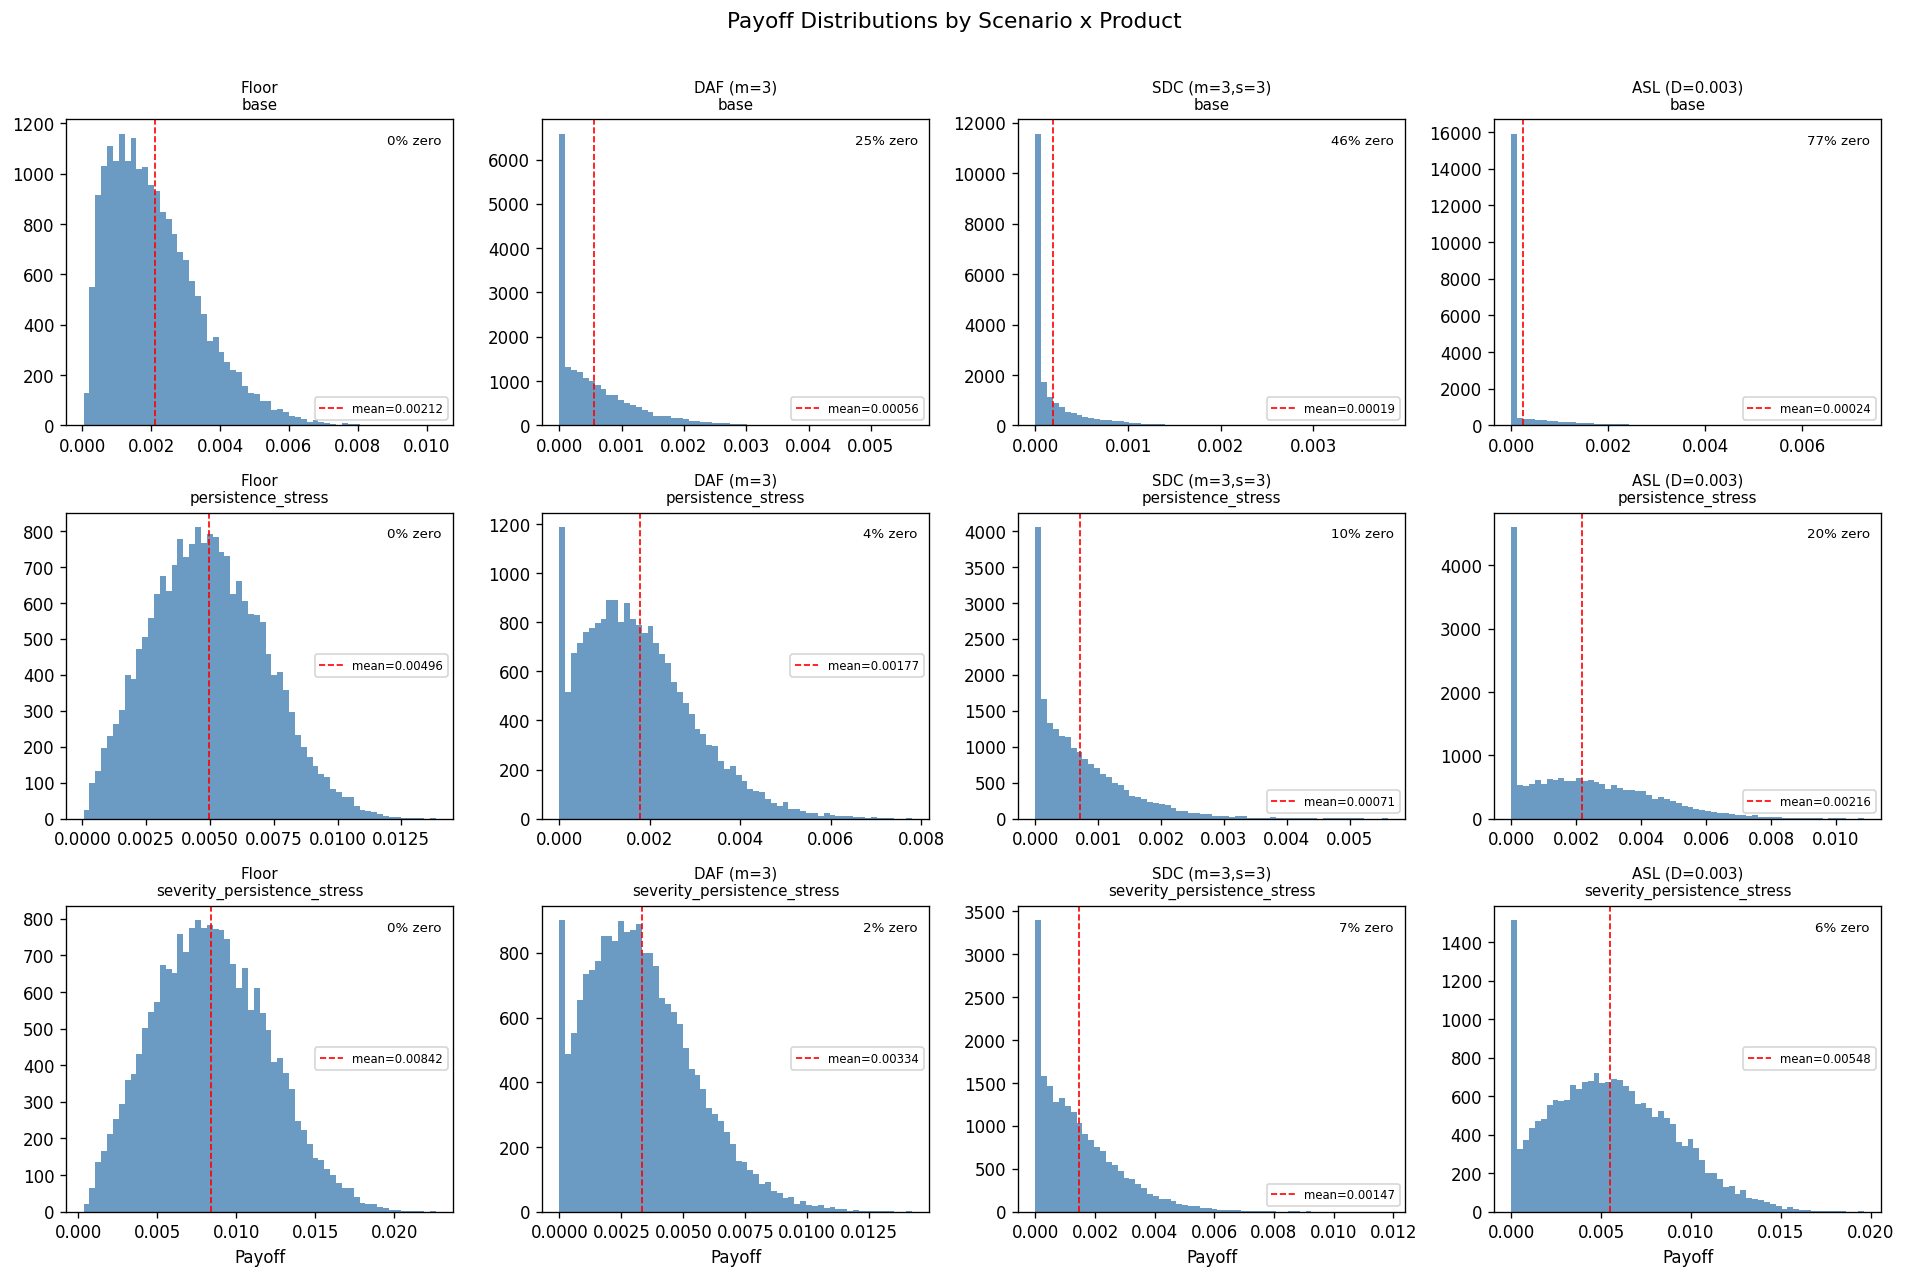

Saved: reports/figures/synth_payoff_distributions.png


In [4]:
fig, axes = plt.subplots(len(SCENARIOS), len(PRODUCTS), figsize=(16, 3.5 * len(SCENARIOS)),
                          sharex=False, sharey=False)

for row, (sc_name, sc_payoffs) in enumerate(payoff_results.items()):
    for col, (prod_name, payoffs) in enumerate(sc_payoffs.items()):
        ax = axes[row, col]
        non_zero = payoffs[payoffs > 0]
        pct_zero = (payoffs == 0).mean() * 100
        ax.hist(payoffs, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
        ax.set_title(f"{prod_name}\n{sc_name}", fontsize=9)
        ax.axvline(payoffs.mean(), color="red", linewidth=1, linestyle="--", label=f"mean={payoffs.mean():.5f}")
        ax.text(0.97, 0.95, f"{pct_zero:.0f}% zero", transform=ax.transAxes, fontsize=8, ha="right", va="top")
        ax.legend(fontsize=7)
        if row == len(SCENARIOS) - 1:
            ax.set_xlabel("Payoff")

fig.suptitle("Payoff Distributions by Scenario x Product", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig("../reports/figures/synth_payoff_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/synth_payoff_distributions.png")

## 3. Premium Decomposition Table

For each scenario x product, compute pure premium, full premium (with risk load + capital charge), and target-Sharpe premium.

In [5]:
premium_rows = []
for sc_name in SCENARIOS:
    for prod_name in PRODUCTS:
        payoffs = payoff_results[sc_name][prod_name]
        prem = compute_premium(
            payoffs, method="all",
            lam=0.35, cost_of_capital=0.12,
            horizon_years=HORIZON_YEARS,
            target_sharpe=0.75, alpha=0.01,
        )
        premium_rows.append({
            "scenario": sc_name,
            "product": prod_name,
            "pure_premium": prem["premium_pure"],
            "risk_load": prem["risk_load"],
            "capital_charge": prem["capital_charge"],
            "full_premium": prem["premium_full"],
            "target_sharpe_premium": prem["premium_target_sharpe"],
        })

df_premiums = pd.DataFrame(premium_rows)

# Format for display (in basis points per 30d)
display_cols = ["pure_premium", "risk_load", "capital_charge", "full_premium", "target_sharpe_premium"]
df_display = df_premiums.copy()
for c in display_cols:
    df_display[c] = (df_display[c] * 10_000).round(2)  # to bps
df_display = df_display.rename(columns={c: f"{c} (bps)" for c in display_cols})
print(df_display.to_string(index=False))

df_premiums.to_csv("../reports/tables/synth_premiums.csv", index=False)
print("\nSaved: reports/tables/synth_premiums.csv")

                   scenario       product  pure_premium (bps)  risk_load (bps)  capital_charge (bps)  full_premium (bps)  target_sharpe_premium (bps)
                       base         Floor               21.18            16.12                  0.66               37.96                        31.07
                       base     DAF (m=3)                5.58             9.43                  0.32               15.34                        10.48
                       base SDC (m=3,s=3)                1.88             6.18                  0.19                8.25                         4.41
                       base ASL (D=0.003)                2.39            12.20                  0.37               14.95                         7.07
         persistence_stress         Floor               49.57            21.30                  1.09               71.96                        66.18
         persistence_stress     DAF (m=3)               17.74            14.45                  0.58

## 4. Hedge Comparison -- Net-CF and Loss-Only Lenses

For each scenario, compare: Unhedged, Swap (at true mean rate), and each DDX product (at full premium). Report both net-CF and loss-only (reserve draw) metrics.

The swap's fixed rate `k` is set to the *true mean per-interval CF* of the scenario -- this is the "ideal" swap rate (non-tradable, but a clean benchmark).

In [6]:
hedge_rows = []

for sc_name, sc_paths in paths.items():
    n = N_PATHS
    # Swap rate: true mean per-interval CF for this scenario
    swap_k = sc_paths.mean()

    # Compute per-path metrics for each strategy
    strategies = {"Unhedged": {"cf": [], "loss": []}}
    strategies[f"Swap (k={swap_k:.6f})"] = {"cf": [], "loss": [], "premium": 0.0}
    for prod_name, spec in PRODUCTS.items():
        payoffs = payoff_results[sc_name][prod_name]
        prem_info = compute_premium(
            payoffs, method="full",
            lam=0.35, cost_of_capital=0.12,
            horizon_years=HORIZON_YEARS, alpha=0.01,
        )
        strategies[prod_name] = {"cf": [], "loss": [], "premium": prem_info["premium"]}

    for i in range(n):
        path = sc_paths[i]
        # Unhedged
        strategies["Unhedged"]["cf"].append(unhedged_cf(path))
        strategies["Unhedged"]["loss"].append(total_loss(path))
        # Swap
        swap_name = f"Swap (k={swap_k:.6f})"
        strategies[swap_name]["cf"].append(swap_hedge_cf(path, swap_k))
        strategies[swap_name]["loss"].append(max(0.0, -len(path) * swap_k))
        # Options
        for prod_name, spec in PRODUCTS.items():
            prem = strategies[prod_name]["premium"]
            strategies[prod_name]["cf"].append(
                option_hedge_cf(path, spec["fn"], prem, **spec["kwargs"])
            )
            strategies[prod_name]["loss"].append(
                option_hedge_loss(path, spec["fn"], prem, **spec["kwargs"])
            )

    # Compute summary statistics
    unhedged_cvar_cf = cvar(np.array(strategies["Unhedged"]["cf"]), 0.01)

    for strat_name, data in strategies.items():
        v_cf = np.array(data["cf"])
        v_loss = np.array(data["loss"])
        prem = data.get("premium", 0.0)
        cvar_cf = cvar(v_cf, 0.01)
        delta_cvar = cvar_cf - unhedged_cvar_cf
        sharpness = delta_cvar / prem if prem > 0 else float("nan")

        hedge_rows.append({
            "scenario": sc_name,
            "strategy": strat_name,
            "premium": prem,
            "mean_cf": v_cf.mean(),
            "std_cf": v_cf.std(),
            "var_1pct_cf": var(v_cf, 0.01),
            "cvar_1pct_cf": cvar_cf,
            "prob_loss_cf": prob_loss(v_cf),
            "mean_loss": v_loss.mean(),
            "cvar_99pct_loss": float(np.quantile(v_loss, 0.99)),
            "sharpness": sharpness,
        })

df_hedges = pd.DataFrame(hedge_rows)

In [7]:
for sc_name in SCENARIOS:
    df_sc = df_hedges[df_hedges["scenario"] == sc_name].copy()
    print(f"\n{'='*80}")
    print(f"Scenario: {sc_name} -- {SCENARIOS[sc_name]['description']}")
    print(f"{'='*80}")

    display = df_sc[[
        "strategy", "premium", "mean_cf", "var_1pct_cf", "cvar_1pct_cf",
        "prob_loss_cf", "mean_loss", "cvar_99pct_loss", "sharpness"
    ]].copy()

    # Convert to bps for readability
    for c in ["premium", "mean_cf", "var_1pct_cf", "cvar_1pct_cf", "mean_loss", "cvar_99pct_loss"]:
        display[c] = (display[c] * 10_000).round(2)
    display["prob_loss_cf"] = (display["prob_loss_cf"] * 100).round(2)
    display["sharpness"] = display["sharpness"].round(2)

    display = display.rename(columns={
        "premium": "Prem (bps)", "mean_cf": "Mean CF (bps)",
        "var_1pct_cf": "VaR1% CF (bps)", "cvar_1pct_cf": "CVaR1% CF (bps)",
        "prob_loss_cf": "P(loss) %", "mean_loss": "Mean Loss (bps)",
        "cvar_99pct_loss": "CVaR99% Loss (bps)", "sharpness": "Sharp."
    })
    print(display.to_string(index=False))


Scenario: base -- Mild bad regime, short episodes - funding mostly positive
         strategy  Prem (bps)  Mean CF (bps)  VaR1% CF (bps)  CVaR1% CF (bps)  P(loss) %  Mean Loss (bps)  CVaR99% Loss (bps)  Sharp.
         Unhedged        0.00          71.22            8.68            -3.64       0.56            21.18               59.78     NaN
Swap (k=0.000079)        0.00          71.22           71.22            71.22       0.00             0.00                0.00     NaN
            Floor       37.96          54.43           26.42            22.03       0.00            37.96               37.96    0.68
        DAF (m=3)       15.34          61.47           13.72             4.90       0.21            30.93               55.42    0.56
    SDC (m=3,s=3)        8.25          64.85            8.67            -2.57       0.52            27.55               60.52    0.13
    ASL (D=0.003)       14.95          58.65           19.43            15.04       0.01            33.74              

## 5. Persistence Sensitivity Sweep

This is the key test for the DAF/SDC "persistence wedge" thesis. We fix the fraction of time spent in the bad state at ~30% and vary the *expected bad run length* by adjusting `p_bad_to_good` (and `p_good_to_bad` accordingly).

We expect:
- **Floor premium**: roughly flat (it pays on all negative funding regardless of persistence)
- **DAF/SDC premium**: increasing with persistence (longer streaks trigger activation more often)
- **Sharpness**: DAF/SDC should become more efficient at high persistence

In [8]:
TARGET_BAD_FRAC = 0.30
P_B2G_VALUES = [0.30, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03]

sweep_rows = []
for p_b2g in P_B2G_VALUES:
    # Solve for p_g2b to hit target bad fraction:
    # stationary P(bad) = p_g2b / (p_g2b + p_b2g) = TARGET
    # => p_g2b = TARGET * p_b2g / (1 - TARGET)
    p_g2b = TARGET_BAD_FRAC * p_b2g / (1.0 - TARGET_BAD_FRAC)
    expected_bad_run = 1.0 / p_b2g
    expected_bad_days = expected_bad_run * 8 / 24

    sim = two_regime_markov(
        n_intervals=N_INTERVALS, n_paths=N_PATHS,
        good_mean_apr=0.12, good_vol_apr=0.10,
        bad_mean_apr=-0.08, bad_vol_apr=0.20,
        p_good_to_bad=p_g2b, p_bad_to_good=p_b2g,
        dt_years=DT_YEARS, seed=SEED,
    )

    for prod_name, spec in PRODUCTS.items():
        payoff_arr = np.array([spec["fn"](sim[i], **spec["kwargs"]) for i in range(N_PATHS)])
        pp = pure_premium(payoff_arr)
        fp = full_premium(payoff_arr, lam=0.35, cost_of_capital=0.12,
                          horizon_years=HORIZON_YEARS, alpha=0.01)

        # Compute sharpness: how much does this product reduce CVaR per unit premium?
        unhedged_cfs = sim.sum(axis=1)
        hedged_cfs = np.array([
            option_hedge_cf(sim[i], spec["fn"], fp["total"], **spec["kwargs"])
            for i in range(N_PATHS)
        ])
        delta_cvar = cvar(hedged_cfs, 0.01) - cvar(unhedged_cfs, 0.01)
        sharpness = delta_cvar / fp["total"] if fp["total"] > 0 else float("nan")

        sweep_rows.append({
            "p_b2g": p_b2g,
            "p_g2b": round(p_g2b, 4),
            "expected_bad_run_intervals": round(expected_bad_run, 1),
            "expected_bad_days": round(expected_bad_days, 1),
            "product": prod_name,
            "pure_premium": pp,
            "full_premium": fp["total"],
            "sharpness": sharpness,
        })

df_sweep = pd.DataFrame(sweep_rows)
print(f"Sweep: {len(P_B2G_VALUES)} persistence levels x {len(PRODUCTS)} products = {len(sweep_rows)} rows")

Sweep: 7 persistence levels x 4 products = 28 rows


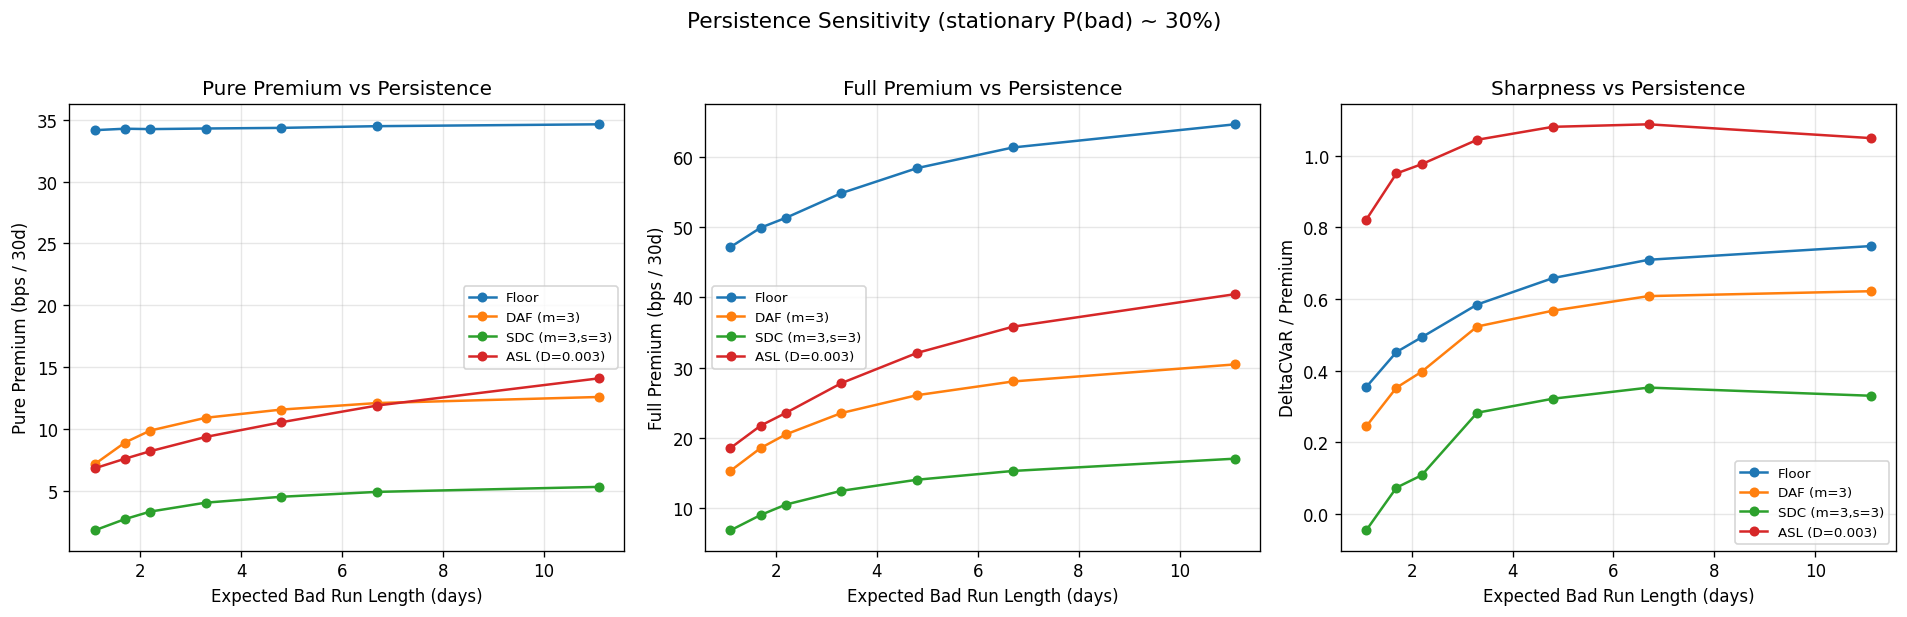

Saved: reports/figures/synth_persistence_sweep.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for prod_name in PRODUCTS:
    df_p = df_sweep[df_sweep["product"] == prod_name]
    x = df_p["expected_bad_days"].values

    axes[0].plot(x, df_p["pure_premium"] * 10_000, "o-", label=prod_name, markersize=5)
    axes[1].plot(x, df_p["full_premium"] * 10_000, "o-", label=prod_name, markersize=5)
    axes[2].plot(x, df_p["sharpness"], "o-", label=prod_name, markersize=5)

axes[0].set_title("Pure Premium vs Persistence")
axes[0].set_ylabel("Pure Premium (bps / 30d)")
axes[1].set_title("Full Premium vs Persistence")
axes[1].set_ylabel("Full Premium (bps / 30d)")
axes[2].set_title("Sharpness vs Persistence")
axes[2].set_ylabel("DeltaCVaR / Premium")

for ax in axes:
    ax.set_xlabel("Expected Bad Run Length (days)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Persistence Sensitivity (stationary P(bad) ~ {TARGET_BAD_FRAC:.0%})", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("../reports/figures/synth_persistence_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/synth_persistence_sweep.png")

## 6. Key Takeaways

**Payoff correctness:**
- All payoffs are non-negative (insurance products never have negative payoff to the buyer).
- Floor has the highest mean payoff (pays on all negative funding). DAF/SDC pay less because they only activate after a persistence filter.
- ASL pays only when aggregate loss exceeds the deductible D, producing many zero payoffs and a heavy right tail.

**Persistence wedge (the core DAF/SDC thesis):**
- The persistence sweep confirms that Floor premium is *roughly flat* as run length increases (it pays on every negative interval regardless of persistence).
- DAF and SDC premiums *increase* with persistence -- they activate more often when bad regimes are longer.
- This means DAF/SDC are cheaper than Floor when persistence is low, and converge toward Floor when persistence is high.

**Sharpness:**
- Sharpness (DeltaCVaR / Premium) measures how much tail risk reduction you get per unit of premium.
- Products with lower premiums (DAF, SDC, ASL) can have higher sharpness even though they provide less absolute tail protection.
- This is the Pareto tradeoff that the hedge frontier visualizes.

**Loss-only lens:**
- The loss-only (reserve draw) metrics confirm that the Floor provides the most absolute loss reduction, while ASL targets only the tail of aggregate losses.
- Premium adds to reserve draw -- even a perfect hedge has residual reserve draw equal to the premium paid.

**Readiness for real data:**
- The pipeline (payoffs → premiums → hedge comparison → metrics) works end-to-end.
- We can now proceed to real data with confidence that the computation engine is correct.

---

### What these results mean for the next notebooks

The synthetic analysis established two key benchmarks that later notebooks will test against real data:
1. **Risk load was 1–2× pure premium** on synthetic data. Real data (NB04) will show whether this holds.
2. **ASL had the highest sharpness; SDC had the lowest.** This led to pruning SDC from the mainline analysis.

**Next → Notebook 02** applies the descriptive analytics framework to real funding-rate data from four exchanges, characterizing the empirical properties (regimes, persistence, tails) that the products must handle.